# Pedestrian Traffic Light Detection and Classification 🚦

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/3_DetectThenClassify_YOLO_SWIN.ipynb)

In this notebook we combine two models:
- **YOLOv10** for object detection, to locate pedestrian traffic lights.
- **Swin Transformer** for image classification, to recognize the light color: `green`, `red`, `yellow`.

This pipeline allows us to detect traffic lights in images or video frames, and decide whether it is safe to cross.

  [1. Environment Setup](#1.-Environment-Setup)  
  [2. Configuration](#2.-Configuration)  
  [3. Helper Functions](#3.-Helper-Functions)  
  [4. Image Inference](#4.-Image-Inference)  
  [5. Video Inference with Zebra Crossing Detection](#5.-Video-Inference-with-Zebra-Crossing-Detection)  
  [6. Conclusion](#6.-Conclusion)

## 1. Environment Setup

If we are running in Google Colab, we need to install dependencies such as Ultralytics YOLO and timm.  
In this section we also import all necessary libraries and select the device (GPU, Apple MPS or CPU) to run the models on.

In [1]:
try:
    import google.colab  # noqa
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)
if IN_COLAB:
    !pip -q install --upgrade ultralytics timm

Mounted at /content/drive
Running on Colab: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.2 MB/s eta 0:00:00


In [2]:
import os, random, time
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import json
from datetime import datetime
from pathlib import Path
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Device (CUDA, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Configuration

Here we set paths to the models, mandatory SWIN parameters.

In [8]:
# ------------------ CONFIG ------------------
# Path to trained YOLO weights (created by the YOLO notebook)
# Path to trained SWIN checkpoint dict (created by the SWIN notebook)
if IN_COLAB:
  YOLO_BEST = "/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/imgsz_896_20250922_183214/weights/best.pt"
  SWIN_BEST = "/content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights/20250925_192601_low_lr.pth"
else:
  YOLO_BEST = '/Users/mothiam/Library/CloudStorage/GoogleDrive-mouhamadou.thiam@stud.hslu.ch/Mon Drive/Computer_Vision_Project/runs/pedestrian_lights/imgsz_896_20250922_183214/weights/best.pt'
  SWIN_BEST = '/Users/mothiam/Library/CloudStorage/GoogleDrive-mouhamadou.thiam@stud.hslu.ch/Mon Drive/Computer_Vision_Project/runs/swin_lights/20250925_192601_low_lr.pth'

# Chec if paths exist
assert Path(YOLO_BEST).exists(), f"YOLO weights not found at {YOLO_BEST}"
assert Path(SWIN_BEST).exists(), f"SWIN checkpoint not found at {SWIN_BEST}"

# SWIN model name + input size (should match what you trained with)
SWIN_MODEL_NAME = "swin_tiny_patch4_window7_224"
SWIN_IMG_SIZE   = 224
SWIN_CLASSES = ["green", "red", "yellow"]
# ------------------------------------------------------

## 3. Helper Functions

We define a series of helper functions to:
- Load Yolo model
- Load Swin model
- Crop the largest detected box
  - In case there are multiple detections, the largest one is most likely the closer to the person and the correct one to consider.
- Run inference with Yolo and Swin with a decision logic

In [9]:
def load_yolo(model_path: str):
    if not Path(model_path).exists():
        raise FileNotFoundError(f"YOLO weights not found: {model_path}")
    return YOLO(model_path)

def load_swin(ckpt_path: str, model_name: str, num_classes: int = 3, img_size: int = 224):
    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"SWIN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)
    classes = SWIN_CLASSES
    model_name = ckpt.get("model_name", model_name)
    img_size = ckpt.get("img_size", img_size)
    model = timm.create_model(model_name, pretrained=False, num_classes=len(classes))
    model.load_state_dict(ckpt["model"] if "model" in ckpt else ckpt)
    model.to(device).eval()

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return model, classes, tfm, img_size

In [10]:
def crop_largest_detection(results, frame_bgr=None, return_pil=False, conf_thr=0.25, class_filter=None):
    """
    results: YOLO result object (from yolo(img) or yolo(frame))
    frame_bgr: if provided, crop will be returned from this array.
    return_pil: if True, return crop as PIL.Image in RGB
    Returns: crop, bbox, conf, clsid  (crop=None if nothing found)
    """
    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return None, None, None, None

    H, W = r.orig_shape
    boxes = r.boxes
    xyxy  = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    clsid = boxes.cls.cpu().numpy().astype(int)

    keep = confs >= conf_thr
    if class_filter is not None:
        keep &= (clsid == class_filter)
    if not np.any(keep):
        return None, None, None, None

    xyxy  = xyxy[keep]
    confs = confs[keep]
    clsid = clsid[keep]

    # largest area
    areas = (xyxy[:,2]-xyxy[:,0]) * (xyxy[:,3]-xyxy[:,1])
    j = int(np.argmax(areas))
    x1,y1,x2,y2 = map(int, xyxy[j])

    # crop
    if frame_bgr is not None:
        crop_bgr = frame_bgr[y1:y2, x1:x2].copy()
        if return_pil:
            from PIL import Image
            crop = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        else:
            crop = crop_bgr
    else:
        crop = None

    return crop, (x1,y1,x2,y2), float(confs[j]), int(clsid[j])


In [11]:
def run_inference_on_images(image_paths, yolo_model, swin_model, swin_tfm, swin_classes, device, conf_threshold=0.6):
    results = []

    for img_path in image_paths:
        print("="*60)
        print(f"Processing: {img_path}")

        # Run YOLO on the image
        results_yolo = yolo_model(str(img_path), conf=0.35, iou=0.5, verbose=False)

        # Read image into BGR (OpenCV)
        frame_bgr = cv2.imread(str(img_path))

        # Crop largest detection (PIL for SWIN)
        crop, bbox, conf, clsid = crop_largest_detection(
            results_yolo, frame_bgr=frame_bgr, return_pil=True, conf_thr=0.35
        )

        # Visualize YOLO annotated image
        annotated_bgr = results_yolo[0].plot()
        plt.figure(figsize=(6,4))
        plt.imshow(annotated_bgr[..., ::-1])  # BGR → RGB
        plt.axis('off')
        plt.title(f"YOLO detections: {Path(img_path).name}")
        plt.show()

        if crop is None:
            print("No pedestrian light detected with current thresholds.")
            results.append({"image": img_path, "detected": False})
            continue

        # SWIN classification
        x = swin_tfm(crop).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = swin_model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = int(np.argmax(probs))
        pred_class = swin_classes[pred_idx]

        # Show crop + prediction
        plt.figure(figsize=(3,3))
        plt.imshow(crop)
        plt.axis('off')
        plt.title(f"Pred: {pred_class} | p={probs[pred_idx]:.2f}")
        plt.show()

        # Walk / Don't Walk decision
        if pred_class == "green" and probs[pred_idx] > conf_threshold:
            decision = "Walk"
        elif pred_class in ["red", "yellow"] and probs[pred_idx] > conf_threshold:
            decision = "Don't Walk"
        else:
            decision = "No light detected"

        # Meta information (from bbox etc.)
        meta = {
            "class_id": clsid,
            "confidence": conf,
            "bbox_xyxy": bbox,
        }

        print("Detection meta:", json.dumps(meta, indent=4))
        print("Class probabilities:", json.dumps(
            {swin_classes[i]: float(probs[i]) for i in range(len(swin_classes))}, indent=4))
        print("-> Decision:", decision)

        results.append({
            "image": img_path,
            "detected": True,
            "prediction": pred_class,
            "prob": float(probs[pred_idx]),
            "decision": decision,
            "probs": {swin_classes[i]: float(probs[i]) for i in range(len(swin_classes))}
        })

    return results


## 4. Image Inference

Here we run a pipeline to process a list of images.  
For each image, we:
- Detect with YOLO the boundinx box of the pedstrian light .
- Crop the pedestrian light.
- Classify it with Swin.
- Show results and make a decision.

In [12]:
# Load models
yolo = load_yolo(YOLO_BEST)
swin, swin_classes, swin_tfm, swin_size = load_swin(SWIN_BEST, SWIN_MODEL_NAME)

Processing: /content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssistSwiss_YOLO_120/val/images/IMG_0006_jpeg.rf.6fce363a7be7799eb7209304a978c5cb.jpg


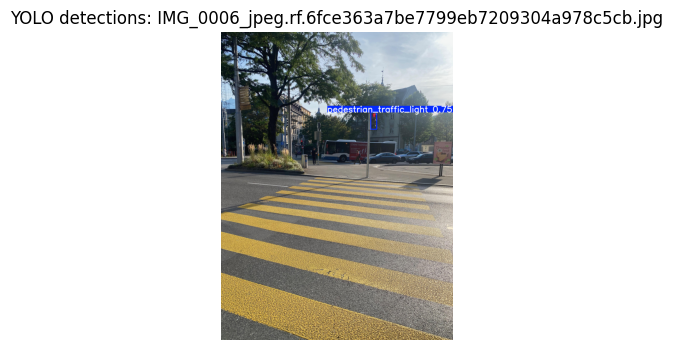

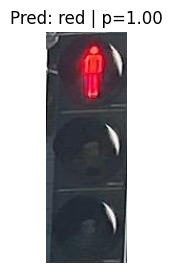

Detection meta: {
    "class_id": 0,
    "confidence": 0.7502169609069824,
    "bbox_xyxy": [
        1952,
        1051,
        2029,
        1272
    ]
}
Class probabilities: {
    "green": 0.00017236753774341196,
    "red": 0.999797523021698,
    "yellow": 3.012383785971906e-05
}
-> Decision: Don't Walk
Processing: /content/drive/MyDrive/Computer_Vision_Project/data/imVisible/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG


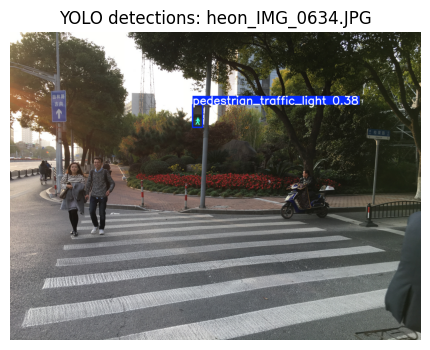

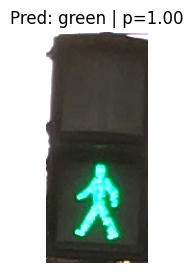

Detection meta: {
    "class_id": 0,
    "confidence": 0.38382941484451294,
    "bbox_xyxy": [
        1791,
        712,
        1889,
        935
    ]
}
Class probabilities: {
    "green": 0.9997225403785706,
    "red": 0.00012115876597817987,
    "yellow": 0.000156185487867333
}
-> Decision: Walk


In [18]:
# Example usage:
if IN_COLAB:
    image_list = [
        "/content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssistSwiss_YOLO_120/val/images/IMG_0006_jpeg.rf.6fce363a7be7799eb7209304a978c5cb.jpg",
        "/content/drive/MyDrive/Computer_Vision_Project/data/imVisible/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG"
    ]
else:
    image_list = [
        "../data/ZebrAssistSwiss_YOLO_120/val/images/IMG_0006_jpeg.rf.6fce363a7be7799eb7209304a978c5cb.jpg",
        "../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG"
    ]

results = run_inference_on_images(image_list, yolo, swin, swin_tfm, swin_classes, device)

We need to emphasize that even chinese traffic lights can be detected and classified correctly, as shown in the last image.  
However the confidence level is 0.38 so more training on these type of traffic lights will be necessary if we want to use our model in China.

## 5. Video Inference with Zebra Crossing Detection

We process video streams in real time:
- **Zebra Crossing Detector**: Detects yellow stripes on the road.
- **YOLOv10 + Swin**: Detects and classifies pedestrian traffic lights.
- **State Machine**:
  - *ZEBRA SEARCH... - LIGHT MODE OFF*: Wait until a zebra crossing is detected.
  - *ZEBRA DETECTED - LIGHT MODE ON*: Once a zebra crossing is detected, look for the traffic light and classify it.
  - Exit light mode if there are no lights anymore for a certain amount of time.


In [ ]:
# ================================
# YOLOv10 + SWIN realtime video loop + Zebra Crossing Detection
# Compatible with both Local and Google Colab (via IN_COLAB flag)
# ================================
import os, time, signal
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import timm
from torchvision import transforms
from PIL import Image
from datetime import datetime

# -------- CONFIG (EDIT THESE) --------
if IN_COLAB:
    VIDEO_SRC = '/content/drive/MyDrive/Computer_Vision_Project/data/videos/MVI_Grenchen.MP4'
else:
    VIDEO_SRC = '../data/videos/MVI_Grenchen.mp4'

# Output path with timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
OUT_PATH = f'{Path(VIDEO_SRC).with_suffix("")}_{timestamp}.mp4'

YOLO_CONF   = 0.4
YOLO_IOU    = 0.50
YOLO_IMGSZ  = 640
DECISION_PERIOD = 0.1   # seconds between YOLO+SWIN runs
DECISION_CONF   = 0.65
SHOW            = True
SAVE            = True

# --- Zebra Crossing Detector Parameters ---
ZEBRA_ROI_REL       = (0.45, 0.95, 0.15, 0.85)
ZEBRA_CHECK_PERIOD  = 0.25
ZEBRA_MIN_WIDTH_FR  = 0.25
ZEBRA_ANGLE_TOL_DEG = 25

YOLO_LOST_TIMEOUT   = 3.0  # exit light mode if no YOLO detection for N sec
target_cls_id       = 0    # only one class in this YOLO model

# -------------------------------------

def swin_predict_rgb(rgb_np: np.ndarray):
    """Classify an RGB crop using Swin."""
    with torch.no_grad():
        x = swin_tfm(Image.fromarray(rgb_np)).unsqueeze(0).to(device)
        probs = torch.softmax(swin(x), dim=1).cpu().numpy()[0]
    idx = int(np.argmax(probs))
    return swin_classes[idx], float(probs[idx])

def detect_zebra_crossing(frame_bgr: np.ndarray,
                          roi_rel=ZEBRA_ROI_REL,
                          min_width_frac=ZEBRA_MIN_WIDTH_FR,
                          angle_accept_deg=ZEBRA_ANGLE_TOL_DEG):
    """Classical CV-based zebra crossing detector using yellow stripes."""
    H, W = frame_bgr.shape[:2]
    y0 = int(roi_rel[0]*H); y1 = int(roi_rel[1]*H)
    x0 = int(roi_rel[2]*W); x1 = int(roi_rel[3]*W)
    roi = frame_bgr[y0:y1, x0:x1]

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    yellow_mask = cv2.inRange(hsv, (15, 80, 150), (35, 255, 255))
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    edges = cv2.Canny(mask, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                            minLineLength=max(20, roi.shape[1]//8), maxLineGap=10)
    if lines is None: return False, None, None
    lines = lines[:,0,:]

    angs = []
    for x1_,y1_,x2_,y2_ in lines:
        dx, dy = x2_-x1_, y2_-y1_
        L = np.hypot(dx, dy)
        if L < 10: continue
        ang = np.degrees(np.arctan2(dy, dx))
        if ang > 90: ang -= 180
        if ang < -90: ang += 180
        angs.append(ang)
    if not angs: return False, None, None

    angs = np.array(angs)
    sel = np.abs(angs) <= angle_accept_deg
    if sel.sum() < 6: return False, None, None

    dom_angle = float(np.median(angs[sel]))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return False, None, None
    cnt = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect).astype(int)
    box[:,0] += x0; box[:,1] += y0

    bbox_w = max(np.linalg.norm(box[0]-box[1]), np.linalg.norm(box[1]-box[2]))
    if bbox_w < min_width_frac * W: return False, None, None
    return True, dom_angle, box

# ---------- Open video ----------
cap = cv2.VideoCapture(VIDEO_SRC)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video source: {VIDEO_SRC}")

src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Source: {VIDEO_SRC} | FPS: {src_fps:.1f} | Size: {w}x{h}")

writer = None
if SAVE:
    Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    if IN_COLAB:
      fourcc = cv2.VideoWriter_fourcc(*"mp4v")
      writer = cv2.VideoWriter(OUT_PATH, fourcc, src_fps, (w, h))
    else:
      fourcc = cv2.VideoWriter_fourcc(*"avc1")  # H.264
      writer = cv2.VideoWriter(OUT_PATH, fourcc, src_fps, (w, h))

# Display setup
if IN_COLAB:
    from google.colab.patches import cv2_imshow
else:
    win = "YOLO+SWIN (realtime look)"
    if SHOW:
        cv2.namedWindow(win, cv2.WINDOW_NORMAL)

# ---------- Realtime loop ----------
STATE_SEARCH_ZEBRA, STATE_LIGHT_MODE = 0, 1
state = STATE_SEARCH_ZEBRA
last_decision, last_color, last_box, last_prob = "No light detected", (20,20,20), None, 0.0
zebra_last_check, last_infer_t, yolo_seen, last_yolo_time = 0.0, 0.0, False, 0.0
t0, frame_idx = time.time(), 0

try:
    while True:
        ok, frame_bgr = cap.read()
        if not ok: break
        frame_idx += 1
        now = time.time()

        if state == STATE_SEARCH_ZEBRA:
            if (now - zebra_last_check) >= ZEBRA_CHECK_PERIOD:
                zebra_ok, _, _ = detect_zebra_crossing(frame_bgr)
                zebra_last_check = now
                if zebra_ok:
                    state = STATE_LIGHT_MODE
                    last_box, last_decision, last_color, last_prob = None, "No light detected", (20,20,20), 0.0
                    yolo_seen, last_yolo_time = False, 0.0
            # Overlay
            text = "ZEBRA SEARCH... - LIGHT MODE OFF"
            (fw, fh), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
            cv2.putText(frame_bgr, text, ((w-fw)//2, h - h//8), cv2.FONT_HERSHEY_SIMPLEX, 1, (220,220,220), 2, cv2.LINE_AA)

        elif state == STATE_LIGHT_MODE:
            if (now - last_infer_t) >= DECISION_PERIOD:
                yres = yolo(frame_bgr, conf=YOLO_CONF, iou=YOLO_IOU, imgsz=YOLO_IMGSZ, verbose=False)
                crop_bgr, bbox, dconf, did = crop_largest_detection(yres, frame_bgr=frame_bgr, return_pil=False, conf_thr=YOLO_CONF, class_filter=target_cls_id)
                if crop_bgr is not None and crop_bgr.size > 0:
                    yolo_seen, last_yolo_time = True, now
                    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
                    pred_class, pred_prob = swin_predict_rgb(crop_rgb)
                    if pred_class == "green" and pred_prob >= DECISION_CONF:
                        last_decision, last_color, last_box, last_prob = "Walk", (0,200,0), bbox, pred_prob
                    elif pred_class in ("red","yellow") and pred_prob >= DECISION_CONF:
                        last_decision, last_color, last_box, last_prob = "Don't Walk", (0,0,220), bbox, pred_prob
                last_infer_t = now
            # Exit rule
            yolo_recent = (now - last_yolo_time) <= YOLO_LOST_TIMEOUT if yolo_seen else True
            if not yolo_recent:
                state, last_box, last_decision, last_color, last_prob, yolo_seen, last_yolo_time = STATE_SEARCH_ZEBRA, None, "No light detected", (20,20,20), 0.0, False, 0.0
            # Overlay
            text = "ZEBRA DETECTED - LIGHT MODE ON"
            (fw, fh), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
            cv2.putText(frame_bgr, text, ((w-fw)//2, h - h//8), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,200,200), 2, cv2.LINE_AA)

        # ---- Decision + Box ----
        if last_box is not None:
            x1,y1,x2,y2 = last_box
            cv2.rectangle(frame_bgr, (x1,y1), (x2,y2), last_color, 2)
        (fw, fh), _ = cv2.getTextSize(last_decision, cv2.FONT_HERSHEY_SIMPLEX, 2, 4)
        cv2.putText(frame_bgr, last_decision, ((w-fw)//2, h//8), cv2.FONT_HERSHEY_SIMPLEX, 2, last_color, 4, cv2.LINE_AA)

        if writer is not None: writer.write(frame_bgr)
        if SHOW:
            if IN_COLAB:
                if frame_idx % int(src_fps) == 0: cv2_imshow(frame_bgr)
            else:
                cv2.imshow(win, frame_bgr)
                if cv2.getWindowProperty(win, cv2.WND_PROP_VISIBLE) < 1: break
                key = cv2.waitKey(max(1, int(1000/src_fps))) & 0xFF
                if key in (27, ord('q')): break

finally:
    cap.release()
    if writer is not None: writer.release()
    if not IN_COLAB and SHOW:
        cv2.destroyWindow(win)
        for _ in range(3): cv2.waitKey(1)

print("✅ Done. Saved:", OUT_PATH if SAVE else "(not saved)")


## GIF DEMO  

![GIF Demo](../assets/MVI_Grenchen.gif)

## 6. Conclusion

We built a **3-stage pedestrian crossing assistance system**:

1. **Zebra Crossing Detection** (OpenCV): ensures that light recognition is only performed near crosswalks.  
2. **YOLOv10 Detection**: detects and crops pedestrian traffic lights in the scene.  
3. **Swin Transformer Classification**: classifies the traffic light color (green, red, yellow) and provides instructions (Walk / Don’t Walk / Off).

This multi-stage design improves reliability and reduces false positives.  
It works on single images, batches of images, and in real-time video.
